# Valutazione dei docenti

Questo notebook è stato selezionato come best project work per la qualità complessiva dell’impostazione e per il livello di maturità mostrato nell’affrontare un problema reale di fraud detection.

Il punto di forza principale è il framing del problema come decisione operativa, con costi asimmetrici esplicitati e utilizzati per guidare la scelta delle metriche e l’ottimizzazione della soglia decisionale. L’accuracy non viene inseguita in modo ingenuo: la valutazione è coerente con lo sbilanciamento della classe e con l’obiettivo di business, attraverso PR-AUC e analisi di scenari di costo. Questo tipo di approccio è tipico di contesti aziendali reali ed è raramente esplicitato con questa chiarezza in un project work.

Molto solida anche la parte di feature engineering, costruita con attenzione alla realisticità temporale delle informazioni e al rischio di data leakage, in particolare per i segnali storici cliente/merchant. Le feature temporali con codifiche cicliche, la distanza geografica (Haversine) e i segnali storici con smoothing sono coerenti con il dominio e ben allineate all’obiettivo di aumentare la separabilità senza introdurre scorciatoie. È apprezzabile anche la discussione critica sui casi in cui alcune scelte migliorano la validation ma peggiorano il test, evidenziando effetti di drift temporale e instabilità statistica.

La modellazione è completa e ben confrontata: baseline semplici, metodi ensemble e boosting, con XGBoost che emerge come soluzione più solida. Lo sbilanciamento viene gestito tramite pesi di classe e la valutazione è sempre guidata dal compromesso operativo tra precision e recall, non da metriche generiche. I risultati in test mostrano differenze coerenti con la natura del problema (ad esempio il collasso del recall della regressione logistica), a conferma della correttezza dell’analisi.

Buona anche la parte di interpretabilità (SHAP) e l’analisi degli errori, inclusa la riflessione sull’overlap di FN e FP tra modelli e sulla possibile estensione a ensemble.

Nel complesso il progetto è sopra la media per maturità end-to-end: dal framing business con proxy dei costi e sensitivity analysis, all’EDA mirata, fino alle scelte di pipeline motivate e discusse.
I principali margini di miglioramento, naturali per portare il lavoro a uno standard pienamente production-grade, riguardano:

una validazione temporale più robusta (ad esempio rolling o più finestre temporali),

una valutazione esplicita della calibrazione delle probabilità,

considerazioni più strutturate su serving, monitoring e retraining in esercizio.


# Credit Card Fraud Detection — Business Understanding & Exploratory Data Analysis - Parte 1

In questo notebook viene affrontato il problema della rilevazione di frodi su transazioni con carta di credito,
utilizzando il *Credit Card Transactions Fraud Detection Dataset*.

Il contesto simulato è quello di una banca o di un emittente di carte di credito che deve monitorare un elevato volume di transazioni in tempo quasi-reale, individuando tempestivamente quelle potenzialmente fraudolente.
Il problema presenta due caratteristiche fondamentali:

- **Forte sbilanciamento delle classi**: le transazioni fraudolente rappresentano una percentuale molto ridotta del totale.
- **Asimmetria dei costi di errore**: una frode non intercettata genera una perdita economica significativa, mentre il blocco errato di una transazione legittima comporta costi operativi e un impatto sull’esperienza del cliente.

Per questo motivo, l’obiettivo non è massimizzare l’accuratezza complessiva, ma costruire un modello che ottimizzi il compromesso tra intercettazione delle frodi e contenimento dei falsi allarmi, in funzione di considerazioni di business.

La prima parte del notebook è dedicata:
- alla comprensione del dataset,
- all’analisi esplorativa delle variabili principali,
- alla stima data-driven dei costi associati alle frodi, che verranno utilizzati successivamente per l’ottimizzazione della soglia decisionale del modello.


In [1]:
#import delle librerie necessarie per:

#Elaborazione dati e grafici
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from itertools import product
import kagglehub

#Costruzione degli algoritmi e aggiunta metriche per la valutazione
import joblib #salvataggio modelli
import shap
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.options.display.float_format = '{:.4f}'.format #per visualizzare la tabella in maniera più leggibile, altrimenti vedremmo i numeri indicati con notazione scientifica

In [2]:
# Download ultima versione
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Path to dataset files:", path)

100%|██████████| 202M/202M [00:10<00:00, 21.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1


### Stima dei costi di business


In assenza di informazioni dirette sui costi di chargeback e gestione delle frodi, si utilizza l’importo delle transazioni fraudolente come proxy del danno economico diretto associato a una frode non intercettata (False Negative).

In particolare, vengono analizzati la media, la mediana e i percentili della distribuzione degli importi fraudolenti, al fine di ottenere una stima robusta
e interpretabile del costo.


In [3]:

df_train = pd.read_csv(path+"/fraudTrain.csv")
df_test  = pd.read_csv(path+"/fraudTest.csv")

df_train["trans_date_trans_time"] = pd.to_datetime(df_train["trans_date_trans_time"])
df_test["trans_date_trans_time"] = pd.to_datetime(df_test["trans_date_trans_time"])

#Dataset di Train e Test già divisi non in maniera randominca, ma in maniera sequenziale.
print(f"Dataset Train - Inizio: {df_train['trans_date_trans_time'].min()} - Fine: {df_train['trans_date_trans_time'].max()}")
print(f"Dataset Test - Inizio: {df_test['trans_date_trans_time'].min()} - Fine: {df_test['trans_date_trans_time'].max()}")
df = pd.concat([df_train, df_test], ignore_index=True)
df.info()

Dataset Train - Inizio: 2019-01-01 00:00:18 - Fine: 2020-06-21 12:13:37
Dataset Test - Inizio: 2020-06-21 12:14:25 - Fine: 2020-12-31 23:59:34
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Unnamed: 0             int64         
 1   trans_date_trans_time  datetime64[ns]
 2   cc_num                 int64         
 3   merchant               object        
 4   category               object        
 5   amt                    float64       
 6   first                  object        
 7   last                   object        
 8   gender                 object        
 9   street                 object        
 10  city                   object        
 11  state                  object        
 12  zip                    int64         
 13  lat                    float64       
 14  long                   float64       
 15  city_pop

Informazioni sul dataset

1. Unnamed: 0  - Unique Identifier for each row
2. trans_date_trans_time - Transaction DateTime
3. cc_num - Credit Card Number of Customer
4. merchant - Merchant Name
5. category - Category of Merchant
6. amt - Amount of Transaction
7. first - First Name of Credit Card Holder
8. last - Last Name of Credit Card Holder
9. gender - Gender of Credit Card Holder
10. street - Street Address of Credit Card Holder
11. city - City of Credit Card Holder
12. state - State of Credit Card Holder
13. zip - Zip of Credit Card Holder
14. lat - Latitude Location of Credit Card Holder
15. long - Longitude Location of Credit Card Holder
16. city_pop - Credit Card Holder's City Population
17. job - Job of Credit Card Holder
18. dob - Date of Birth of Credit Card Holder
19. trans_num - Transaction Number
20. unix_time - UNIX Time of transaction
21. merch_lat - Latitude Location of Merchant
22. merch_long - Longitude Location of Merchant
23. is_fraud - Fraud Flag <--- Target Class    


In [4]:
df.drop(columns=["Unnamed: 0"], inplace=True, errors="ignore") #rimossa perchè un indice non utile all'analisi


In [5]:
print("Shape dataset di Train ", df_train.shape)
print("Shape dataset di Test ", df_test.shape)
print("Shape dataset totale ", df.shape) #il df concatenato verrà utilizzato ai fini di analisi esplorativa


Shape dataset di Train  (1296675, 23)
Shape dataset di Test  (555719, 23)
Shape dataset totale  (1852394, 22)


In [7]:
# Selezione degli importi delle sole transazioni fraudolente,
# utilizzati come proxy del costo economico di una frode non intercettata (False Negative).

fraud_amt = df.loc[df["is_fraud"] == 1, "amt"]

fraud_amt.describe(percentiles=[0.5, 0.9, 0.95, 0.99])


,amt
count,9651.0000
mean,530.6614
std,391.0289
min,1.0600
50%,390.0000
90%,1024.6100
95%,1084.0900
99%,1175.8500
max,1376.0400


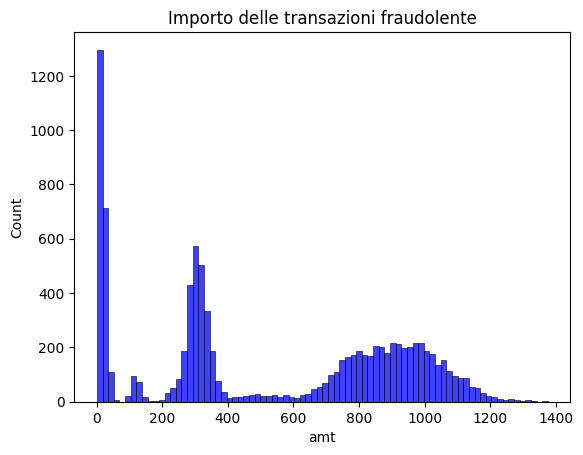

In [8]:
sns.histplot(fraud_amt, color="blue", bins=80)
plt.title("Importo delle transazioni fraudolente")
plt.show()

### Stima del costo delle frodi

L’analisi della distribuzione degli importi delle transazioni fraudolente mostra una forte asimmetria,
con una coda destra pronunciata. La mediana dell’importo fraudolento è pari a circa 390 €, mentre la media
è pari a circa 531 €, indicando la presenza di frodi di importo elevato che influenzano la media.

Per evitare che il costo associato a una frode non intercettata sia eccessivamente influenzato da outlier,
si utilizza la **mediana dell’importo fraudolento** come stima principale del costo di un falso negativo.
La media e i percentili superiori verranno invece utilizzati per un’analisi di sensibilità sui costi.

Sensitivity analysis
| Scenario     | Cost_FN (€) | Motivazione        |
|--------------|-------------|--------------------|
| Conservativo | 300         | Sotto la mediana   |
| Base         | 390         | Mediana            |
| Medio-alto   | 530         | Media              |
| Alto         | 1000        | ~90° percentile    |


###Analisi Esplorativa
Vengono analizzati i seguenti punti:
- Distribuzione delle classi
- Distribuzione dell’importo
- Pattern temporali
- Analisi per categoria e merchant
- Analisi geografica cliente–merchant

In [ ]:
duplicated = df.duplicated().sum() #Check se vi sono righe duplicate
print(f"Numero di righe duplicate: {duplicated}")

Numero di righe duplicate: 0


In [ ]:
## Distribuzione delle Classi

#Utilizziamo ancora la concatenazione di entrambi i dataset per l'analisi

class_counts = df["is_fraud"].value_counts()
class_ratio = df["is_fraud"].value_counts(normalize=True)

print(f"{'Transazioni non fraudolente:':<30} Conteggio {class_counts[0]:<10}, Perc. {class_ratio[0]:.2%}")
print(f"{'Transazioni fraudolente:':<30} Conteggio {class_counts[1]:<10}, Perc. {class_ratio[1]:.2%}")


Transazioni non fraudolente:   Conteggio 1842743   , Perc. 99.48%
Transazioni fraudolente:       Conteggio 9651      , Perc. 0.52%


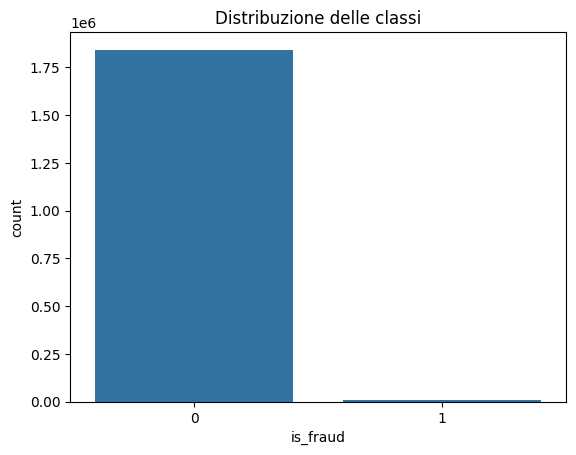

In [ ]:
#La classe fraudolenta è estremamente minoritaria rispetto alle transazioni legittime.
sns.countplot(x="is_fraud", data=df)
plt.title("Distribuzione delle classi")
plt.show()

Il dataset presenta un forte sbilanciamento delle classi: le transazioni fraudolente rappresentano meno dell’1% del totale.
Questo rende il problema particolarmente complesso; di conseguenza, metriche come l’accuratezza risultano poco informative, mentre recall, precision, F1-score e AUC-PR saranno privilegiate nelle fasi successive, in quanto più adatte ad un contesto di imbalanced learning

Distribuzione degli importi in caso di Frode


,amt
count,9651.0000
mean,530.6614
std,391.0289
min,1.0600
25%,240.0750
50%,390.0000
75%,902.3650
max,1376.0400


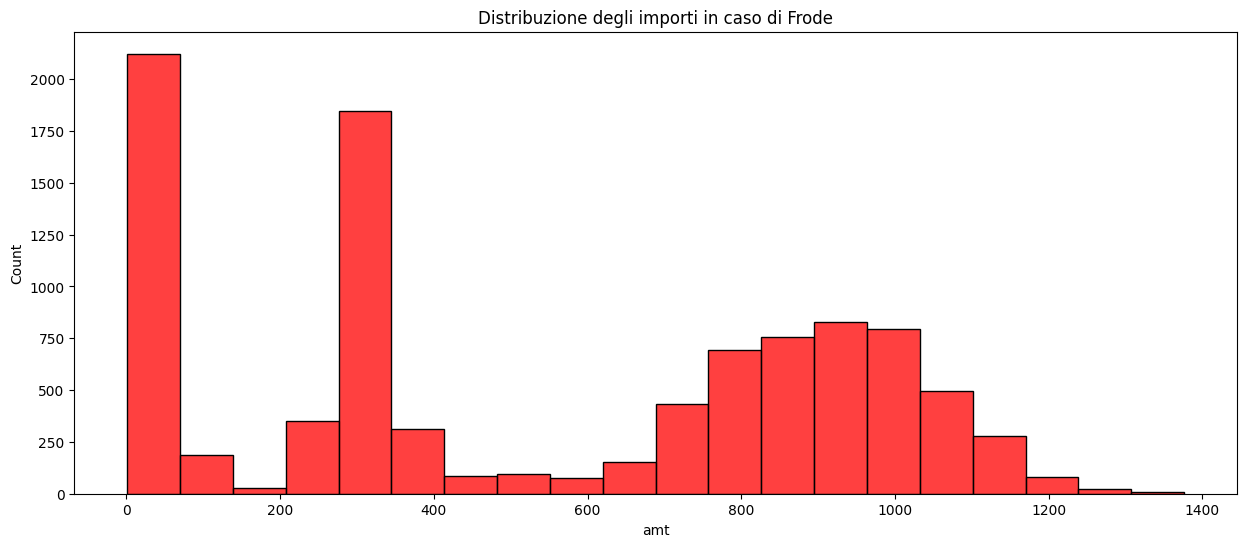

In [9]:
## Distribuzione dell'Importo
print("Distribuzione degli importi in caso di Frode")
display(df[df["is_fraud"]==1]["amt"].describe())

plt.figure(figsize=(15,6))
sns.histplot(df[df["is_fraud"]==1]["amt"], color="red", label="Fraud", bins=20)
plt.title("Distribuzione degli importi in caso di Frode")
plt.show()

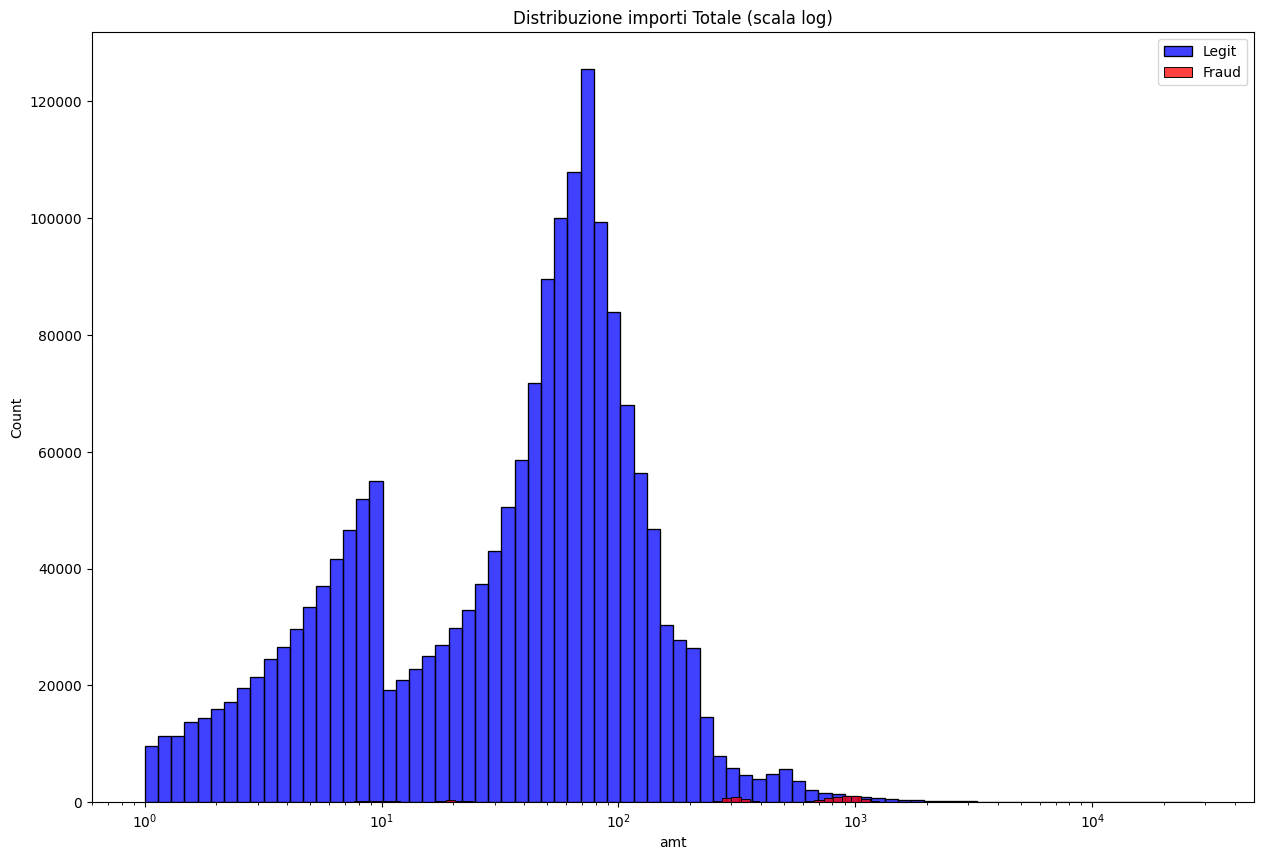

In [12]:
plt.figure(figsize=(15,10))
sns.histplot(df[df["is_fraud"]==0]["amt"], log_scale=True, color="blue", label="Legit", bins=80)
sns.histplot(df[df["is_fraud"]==1]["amt"], log_scale=True, color="red", label="Fraud", bins=80)
plt.legend()
plt.title("Distribuzione importi Totale (scala log)")
plt.show()


Il primo grafico, relativo alle sole transazioni fraudolente, mostra una distribuzione fortemente asimmetrica con una coda destra pronunciata, confermando la presenza di frodi di importo elevato che influenzano la media. Questo supporta l’utilizzo della mediana come stima più robusta del costo associato a una frode non intercettata.

Il secondo grafico, che confronta transazioni legittime e fraudolente in scala logaritmica, evidenzia come le frodi tendano in media ad avere importi più elevati, ma anche una significativa sovrapposizione tra le due classi lungo l’intero range degli importi. Questo indica che l’importo della transazione, pur essendo informativo, non è sufficiente da solo per discriminare le frodi, rendendo necessaria l’integrazione con ulteriori variabili temporali, geografiche e comportamentali

In [13]:
## Pattern Temporali
print("Data di inizio ", df["trans_date_trans_time"].min()) # 2019-01-01
print("Data ultima ", df["trans_date_trans_time"].max()) # 2020-12-31

def time_features(df):
  df["hour"] = df["trans_date_trans_time"].dt.hour
  df["dow"] = df["trans_date_trans_time"].dt.dayofweek
  df["month"] = df["trans_date_trans_time"].dt.month
  df["year"] = df["trans_date_trans_time"].dt.year #Solo per vedere se il tasso di frode è aumentato rispetto all'anno precedente

time_features(df)

Data di inizio  2019-01-01 00:00:18
Data ultima  2020-12-31 23:59:34


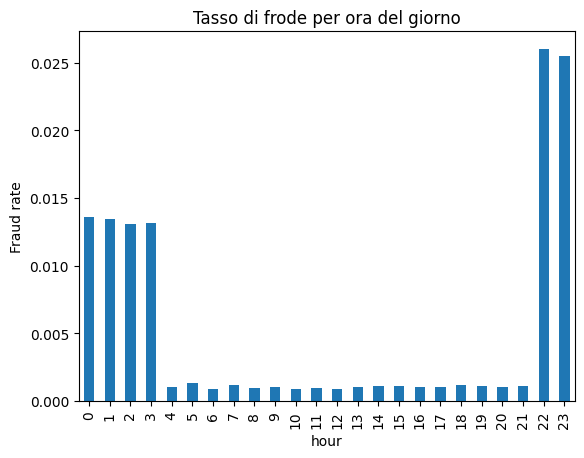

In [14]:
df.groupby("hour")["is_fraud"].mean().plot(kind="bar") #calcoliamo per ogni ora, sul totale delle transazioni, la percentuale di frodi
plt.title("Tasso di frode per ora del giorno")
plt.ylabel("Fraud rate")
plt.show()


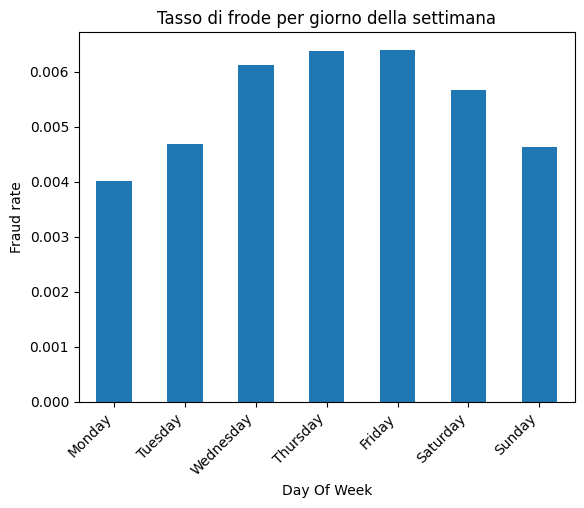

In [15]:
df.groupby("dow")["is_fraud"].mean().plot(kind="bar")
plt.title("Tasso di frode per giorno della settimana")
plt.ylabel("Fraud rate")
plt.xlabel("Day Of Week")
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], rotation=45, ha='right')
plt.show()

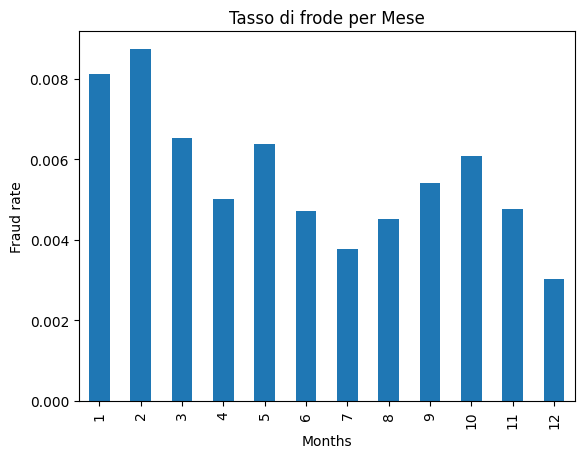

In [16]:
df.groupby("month")["is_fraud"].mean().plot(kind="bar")
plt.title("Tasso di frode per Mese")
plt.ylabel("Fraud rate")
plt.xlabel("Months")
plt.show()

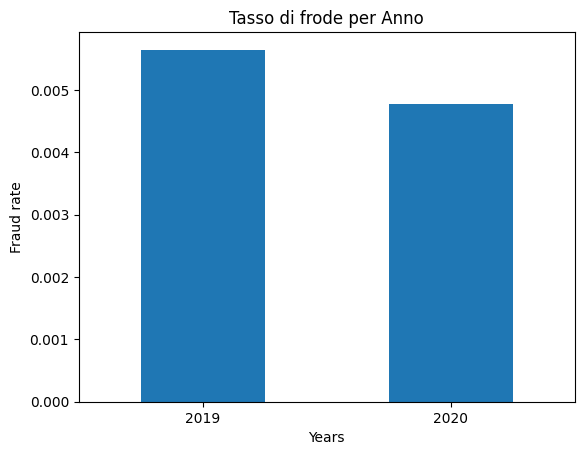

In [17]:
df.groupby("year")["is_fraud"].mean().plot(kind="bar")
plt.title("Tasso di frode per Anno")
plt.ylabel("Fraud rate")
plt.xticks(rotation=0, ha='center')
plt.xlabel("Years")
plt.show()
#Sarebbe rassicurante vedere questo grafico su un caso reale, vorrebbe dire che il numero di frodi rispetto all'anno precedente è diminuito

L’analisi temporale evidenzia pattern ricorrenti nelle transazioni fraudolente. In particolare, il tasso di frode risulta più elevato nelle ore notturne, suggerendo un comportamento non uniforme nel corso della giornata.

A livello settimanale, si osservano differenze tra i giorni, con un rischio maggiore concentrato nei giorni feriali centrali rispetto al fine settimana. Anche l’analisi mensile mostra una variabilità stagionale del tasso di frode.

Questi risultati giustificano l’introduzione di feature temporali esplicite nel modello, in quanto il tempo fornisce un segnale informativo rilevante per la rilevazione delle frodi

In [18]:
## Analisi per categoria

cat_fraud = df.groupby("category")["is_fraud"].mean().sort_values(ascending=False)

cat_count = df["category"].nunique()
print(f"Numero di Categorie: {cat_count}")

cat_fraud.head(14)


Numero di Categorie: 14


,is_fraud
category,
shopping_net,0.0159
misc_net,0.0130
grocery_pos,0.0126
shopping_pos,0.0063
gas_transport,0.0041
misc_pos,0.0028
grocery_net,0.0027
travel,0.0027
personal_care,0.0022


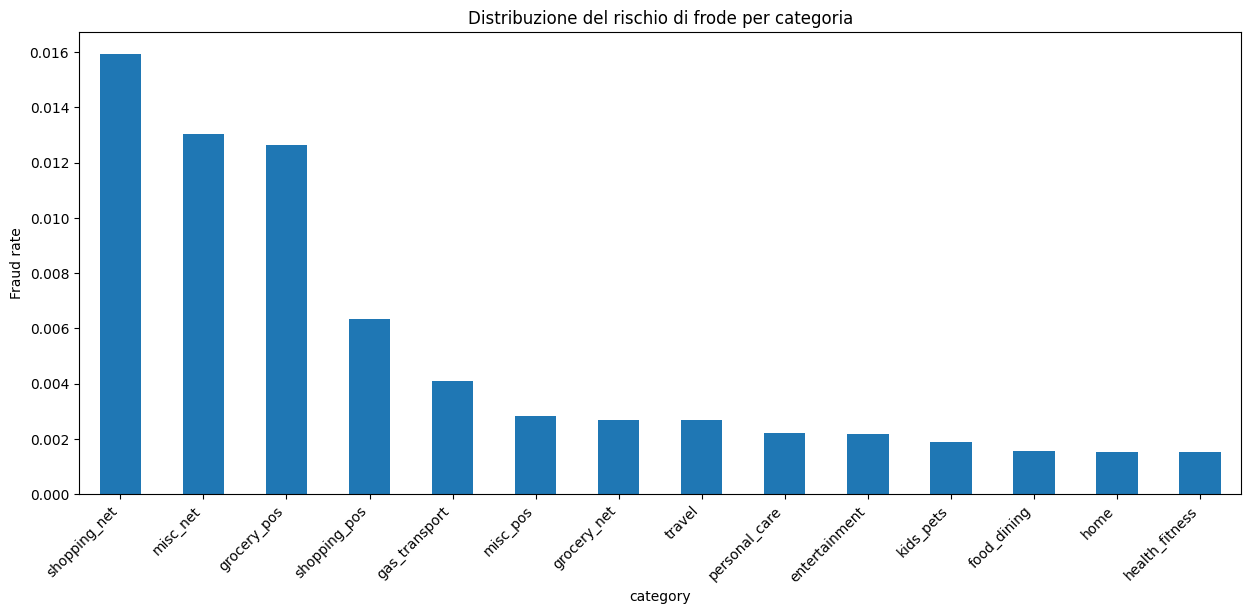

In [19]:
cat_fraud.plot(kind="bar", figsize=(15,6))
plt.title("Distribuzione del rischio di frode per categoria")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Fraud rate")
plt.show()


In [20]:
## Analisi per Merchant

merchant_fraud = df.groupby("merchant")["is_fraud"].mean().sort_values(ascending=False)
display(merchant_fraud.describe(percentiles=[0.25,0.5, 0.75, 0.8,0.9, 0.99]))

merchants_count = df["merchant"].nunique()
print(f"Numero di merchant: {merchants_count}")

,is_fraud
count,693.0000
mean,0.0051
std,0.0050
min,0.0000
25%,0.0017
50%,0.0027
75%,0.0067
80%,0.0100
90%,0.0139
99%,0.0185


Numero di merchant: 693


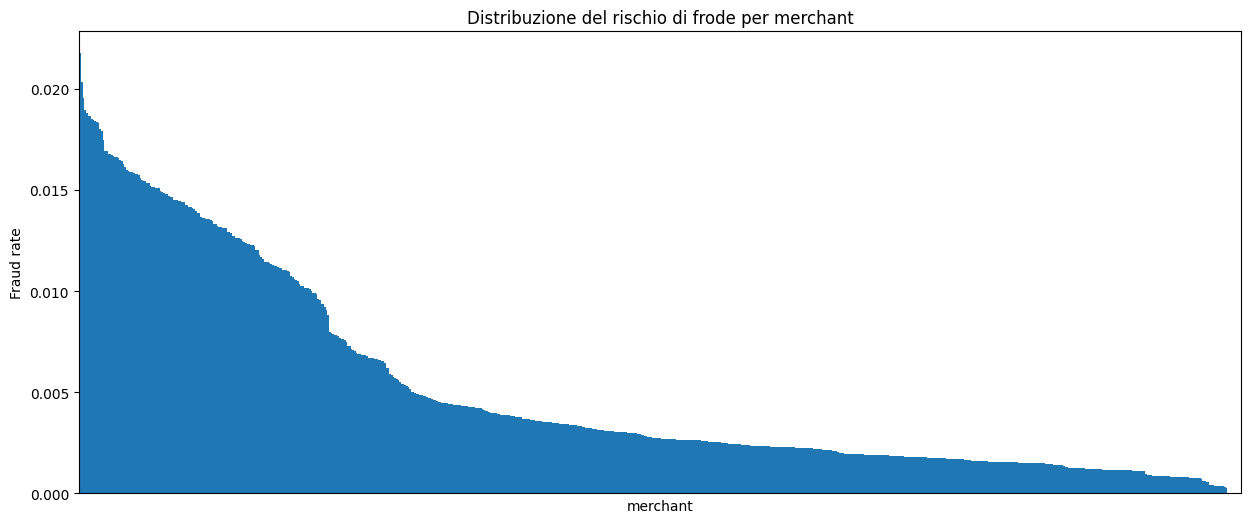

In [21]:
merchant_fraud.plot(kind="bar", figsize=(15,6), width=1)
plt.title("Distribuzione del rischio di frode per merchant")
plt.xticks(visible=False) # Nasconde le etichette dell'asse X
plt.tick_params(axis='x', which='both', bottom=False, top=False) # Nasconde le tacchette dell'asse X
plt.ylabel("Fraud rate")
plt.show()

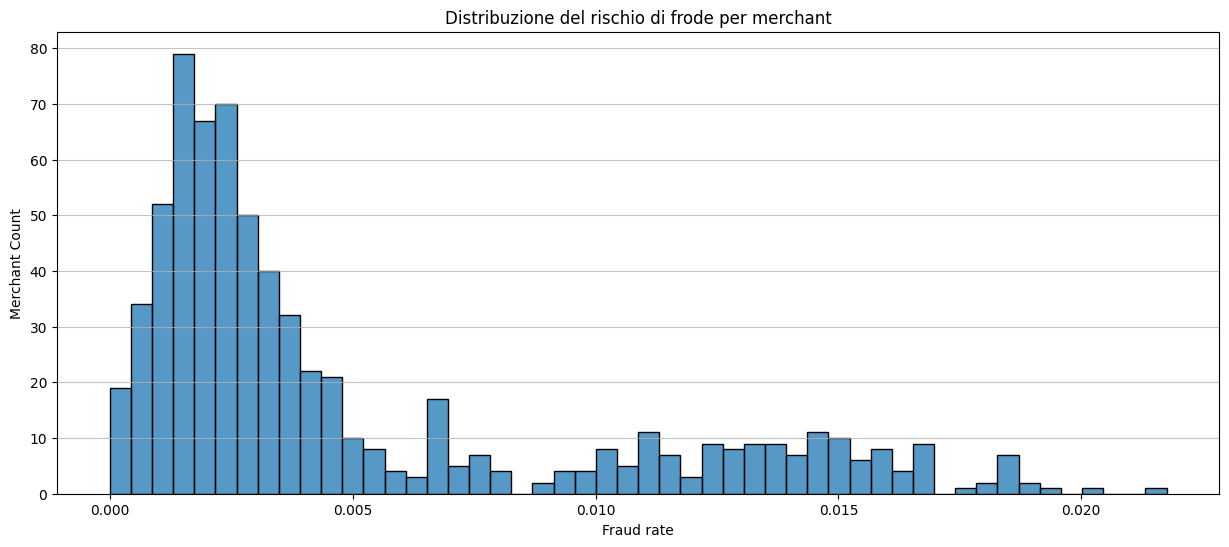

In [22]:
plt.figure(figsize=(15,6))
sns.histplot(merchant_fraud, bins=50)
plt.title("Distribuzione del rischio di frode per merchant")
plt.xlabel("Fraud rate")
plt.ylabel("Merchant Count")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [23]:
perc_line = int(merchants_count*20/100)

In [24]:
print(f"Indicatore aggregato di rischio (tutti i merchant): {merchant_fraud.sum():.3f}")
print(f"Indicatore aggregato di rischio - top 20% merchant: {merchant_fraud[:perc_line].sum():.3f}")
print(f"Indicatore aggregato di rischio - restante 80% merchant: {merchant_fraud[perc_line:].sum():.3f}")


Indicatore aggregato di rischio (tutti i merchant): 3.506
Indicatore aggregato di rischio - top 20% merchant: 1.946
Indicatore aggregato di rischio - restante 80% merchant: 1.560


L’analisi per categoria e merchant evidenzia che entrambe le variabili sono fortemente informative ai fini della rilevazione delle frodi.
In particolare, alcune categorie (come shopping_net, misc_net e grocery_pos) mostrano tassi di frode significativamente più elevati rispetto alla media del dataset, suggerendo una maggiore esposizione al rischio in specifici contesti di spesa.

Analogamente, il rischio di frode associato ai merchant presenta una distribuzione fortemente eterogenea, con una chiara concentrazione del rischio: una quota relativamente ridotta di merchant (circa il 20%) concentra una parte rilevante del rischio aggregato, indicando un effetto di tipo Pareto.

Tuttavia, anche per i merchant più esposti, il tasso di frode rimane ampiamente inferiore al 3%, evidenziando come nessuna singola categoria o merchant possa essere considerato deterministico.
Questo comportamento rende le variabili merchant e categoria particolarmente adatte a essere trasformate in feature di rischio storico smoothed, calcolate in modo leakage-safe, piuttosto che utilizzate tramite codifiche one-hot ad alta dimensionalità.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


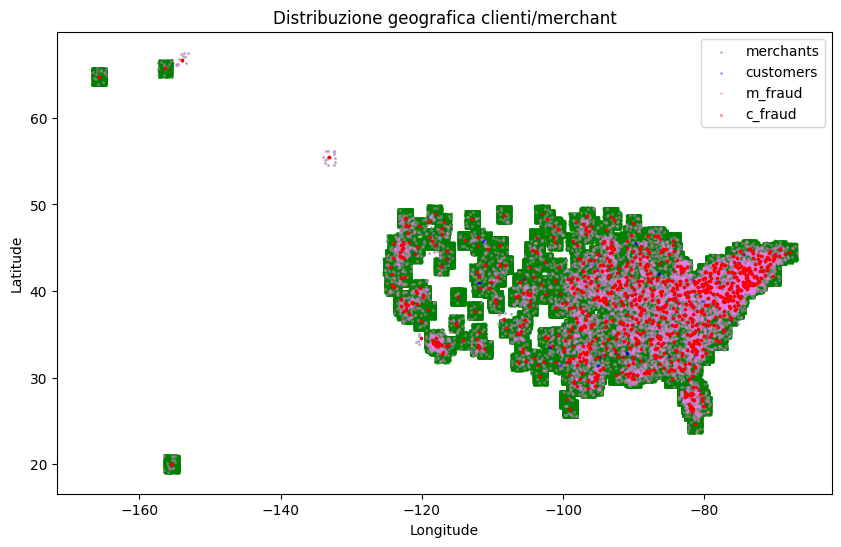

In [25]:
## Analisi geografica cliente–merchant

df_fraud = df[df['is_fraud'] == 1]
plt.figure(figsize=(10,6))
plt.scatter(df["merch_long"], df["merch_lat"], color='green', s=1, alpha=0.3, label='merchants')
plt.scatter(df["long"], df["lat"], color='blue', s=1, alpha=0.3, label='customers')
plt.scatter(df_fraud["merch_long"], df_fraud["merch_lat"], color='violet', s=2, alpha=0.3, label='m_fraud')
plt.scatter(df_fraud["long"], df_fraud["lat"], color='red', s=2, alpha=0.3, label='c_fraud')
plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribuzione geografica clienti/merchant")
plt.show()


In [26]:
# Ora che abbiamo dato un'occhiata su dove ci troviamo andiamo a rispondere ad una domanda importante:
# che distanza c'è tra il cliente e il commerciante in ogni transazione?

#Calcolo la distanza in km tra due punti sulla superficie terrestre: formula di Haversine


def haversine(df):

    R = 6371  # raggio medio della Terra in km

    lat1 = df["lat"]
    lon1 = df["long"]
    lat2 = df["merch_lat"]
    lon2 = df["merch_long"]

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


In [27]:
df["cust_merch_km"] = haversine(df)


In [28]:
df["cust_merch_km"].describe(percentiles=[0.25, 0.5,0.75, 0.9, 0.95, 0.99])


,cust_merch_km
count,1852394.0000
mean,76.1117
std,29.1170
min,0.0223
25%,55.3201
50%,78.2164
75%,98.5095
90%,112.8179
95%,120.4996
99%,132.0195


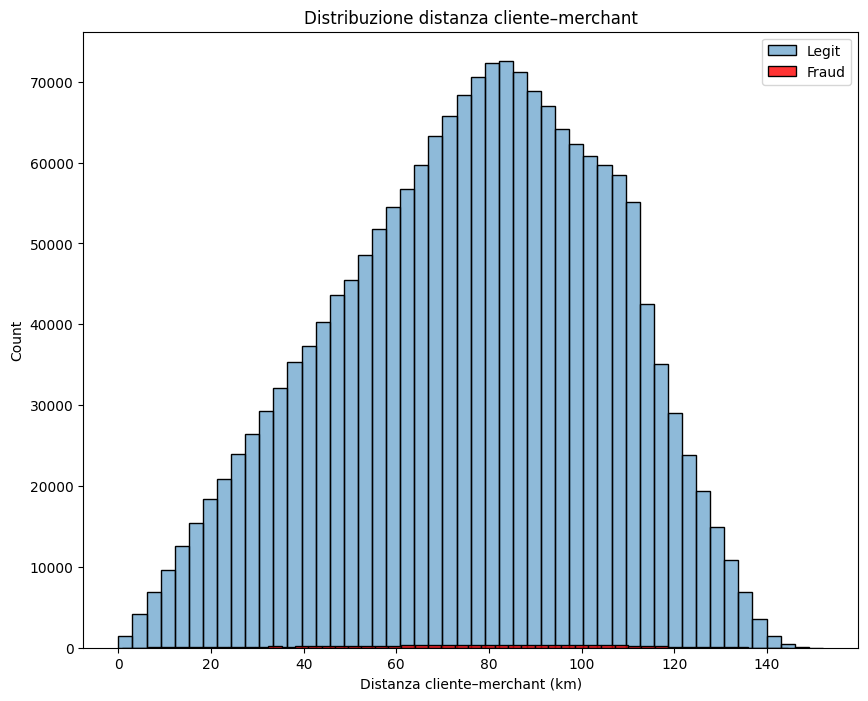

In [29]:
plt.figure(figsize=(10,8))
sns.histplot(df[df["is_fraud"] == 0]["cust_merch_km"], bins=50, label="Legit", alpha=0.5)
sns.histplot(df[df["is_fraud"] == 1]["cust_merch_km"], bins=50, label="Fraud", color='red', alpha=0.8)

plt.legend()
plt.xlabel("Distanza cliente–merchant (km)")
plt.title("Distribuzione distanza cliente–merchant")
plt.show()

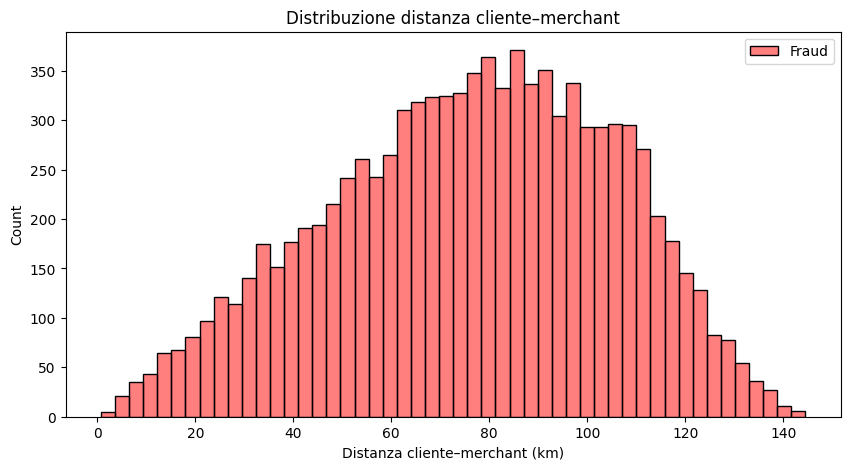

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(df[df["is_fraud"] == 1]["cust_merch_km"], bins=50, color='red', label="Fraud", alpha=0.5)

plt.legend()
plt.xlabel("Distanza cliente–merchant (km)")
plt.title("Distribuzione distanza cliente–merchant")
plt.show()

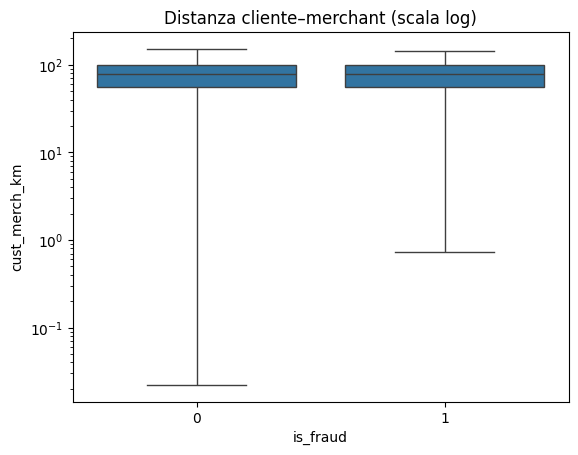

In [31]:
sns.boxplot(x="is_fraud", y="cust_merch_km", data=df)
plt.yscale("log")
plt.title("Distanza cliente–merchant (scala log)")
plt.show()


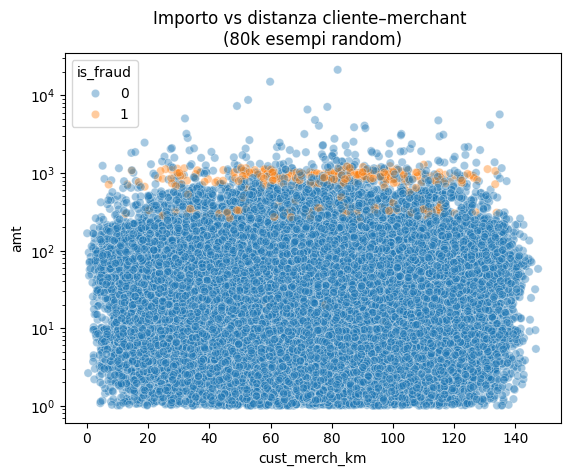

In [32]:
sns.scatterplot(
    x="cust_merch_km",
    y="amt",
    hue="is_fraud",
    data=df.sample(80000, random_state=42),
    alpha=0.4
)
#plt.xscale("log")
plt.yscale("log")
plt.title("Importo vs distanza cliente–merchant \n(80k esempi random)")
plt.show()


L’analisi della distanza geografica tra cliente e merchant mostra che le distribuzioni delle transazioni legittime e fraudolente risultano ampiamente sovrapposte. In particolare, entrambe le classi presentano una distribuzione unimodale con un picco in corrispondenza di distanze intermedie, suggerendo che la distanza assoluta non costituisca un fattore discriminante sufficiente per l’individuazione delle frodi.
L’analisi congiunta con l’importo della transazione evidenzia inoltre che le frodi tendono a concentrarsi su importi mediamente più elevati, indipendentemente dalla distanza cliente–merchant. Questo indica che la distanza geografica fornisce un segnale informativo debole se considerata isolatamente, ma può contribuire all’identificazione di comportamenti anomali quando combinata con altre variabili, quali l’importo, il contesto temporale e il comportamento storico del cliente.
Nel complesso, i risultati suggeriscono che la distanza cliente–merchant debba essere interpretata come una feature di supporto, utile all’interno di un modello multivariato, piuttosto che come una regola deterministica di classificazione.


###Analisi ultime feature del dataset
In ultima analisi andiamo a verificare quali feature sarà necessario categorizzare e quali invece andrebbero eliminate o meglio modificate per cercare di mantenere informazioni utili al modello (le feature barrate sono quelle già esaminate in precedenza)

1. ~~Unnamed: 0  - Unique Identifier for each row~~
2. ~~trans_date_trans_time - Transaction DateTime~~
3. cc_num - Credit Card Number of Customer
4. ~~merchant - Merchant Name~~
5. ~~category - Category of Merchant~~
6. ~~amt - Amount of Transaction~~
7. first - First Name of Credit Card Holder
8. last - Last Name of Credit Card Holder
9. gender - Gender of Credit Card Holder
10. street - Street Address of Credit Card Holder
11. city - City of Credit Card Holder
12. state - State of Credit Card Holder
13. zip - Zip of Credit Card Holder
14. ~~lat - Latitude Location of Credit Card Holder~~
15. ~~long - Longitude Location of Credit Card Holder~~
16. city_pop - Credit Card Holder's City Population
17. job - Job of Credit Card Holder
18. dob - Date of Birth of Credit Card Holder
19. trans_num - Transaction Number
20. unix_time - UNIX Time of transaction
21. ~~merch_lat - Latitude Location of Merchant~~
22. ~~merch_long - Longitude Location of Merchant~~
23. ~~is_fraud - Fraud Flag <--- Target Class~~

In [33]:
#creiamo prima 3 ulteriori feature numeriche, age_years, log_amt e log_cust_merch_km e vediamo se ha senso aggiungerle

df["age_years"] = (pd.to_datetime(df["trans_date_trans_time"]) - pd.to_datetime(df["dob"])).dt.days / 365.25
df["log_amt"] = np.log1p(df["amt"].clip(lower=0))
df["log_cust_merch_km"] = np.log1p(df["cust_merch_km"].clip(lower=0))

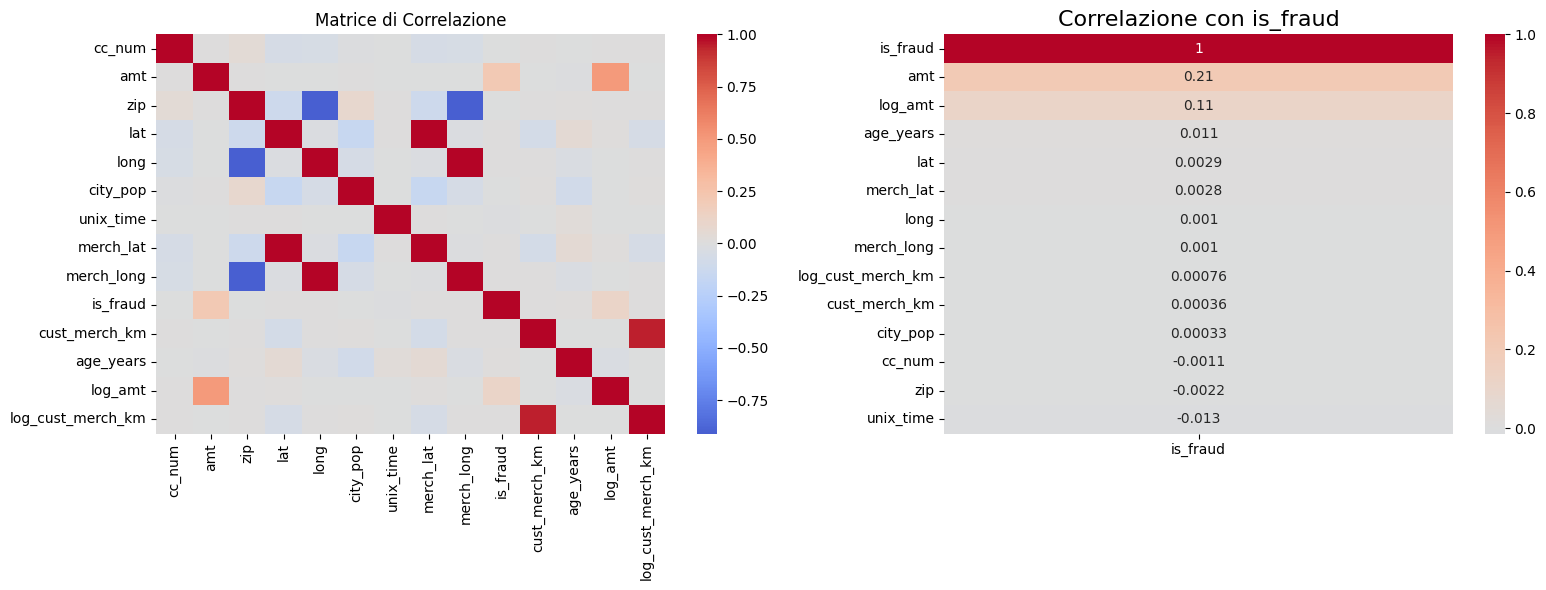

In [34]:
## Matrice di correlazione

# Effettuiamo comunque un controllo su tutte le feature numeriche per ottenere maggiori info
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_with_target = numeric_df.corr()['is_fraud'].sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, ax=ax1)
ax1.set_title("Matrice di Correlazione")
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title("Correlazione con is_fraud", fontsize=16)
plt.tight_layout()
plt.show()

È stata analizzata la matrice di correlazione tra le principali feature numeriche e la variabile target is_fraud. I risultati mostrano che, ad eccezione dell’importo della transazione, nessuna singola variabile presenta una correlazione lineare significativa con il target.

In particolare, l’importo (amt) risulta moderatamente correlato con is_fraud, mentre la maggior parte delle altre feature mostra correlazioni prossime allo zero. Questo comportamento è coerente con la natura del problema di fraud detection, caratterizzato da relazioni non lineari e da segnali deboli che emergono principalmente attraverso combinazioni di variabili piuttosto che tramite effetti lineari isolati.

L’analisi evidenzia inoltre la presenza di forti correlazioni tra alcune feature derivate e le rispettive variabili originali (ad esempio tra coordinate geografiche e distanza cliente–merchant, o tra importo e sua trasformazione logaritmica), giustificando la rimozione delle feature ridondanti nella fase di preprocessing.

Nel complesso, i risultati suggeriscono che la selezione delle feature non debba basarsi esclusivamente su metriche di correlazione lineare, ma su valutazioni più ampie che tengano conto di relazioni non lineari, pattern temporali e informazioni storiche, motivando l’utilizzo di modelli supervisionati in grado di catturare tali complessità.

In [41]:
## Controllo sulle Feature Object (+ cc_num, zip, - dob, trans_num)
df_object = df.select_dtypes(include=['object'])
df_object = df_object.drop(columns=["dob", "trans_num"])
df_object = pd.concat([df_object, df["cc_num"], df["zip"]], axis=1)
df_object["cc_num"] = df_object["cc_num"].astype(str)
df_object["zip"] = df_object["zip"].astype(str)
df_object.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 11 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   merchant  object
 1   category  object
 2   first     object
 3   last      object
 4   gender    object
 5   street    object
 6   city      object
 7   state     object
 8   job       object
 9   cc_num    object
 10  zip       object
dtypes: object(11)
memory usage: 155.5+ MB


In [42]:
df_object.nunique()

,0
merchant,693
category,14
first,355
last,486
gender,2
street,999
city,906
state,51
job,497
cc_num,999


In [43]:
df_object = pd.concat([df_object, df["is_fraud"]], axis=1)

In [47]:
def plot_top_fraud_on_ax(df, col, ax, top_n=10):
    stats = (
        df.groupby(col)["is_fraud"]
          .agg(n_fraud="sum", n_txn="count")
    )
    stats["fraud_rate"] = stats["n_fraud"] / stats["n_txn"]
    stats_rate = stats.sort_values("fraud_rate", ascending=False).head(20) #elenco ordinato per fraud rate che utilizzeremo dopo
    stats = stats.sort_values("n_fraud", ascending=False).head(top_n)

    # Bar plot: numero frodi
    stats["n_fraud"].plot(kind="bar", ax=ax, color="red", alpha=0.7)
    ax.set_ylabel("N. frodi")
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", rotation=90)

    # Line plot: fraud rate (secondo asse)
    ax2 = ax.twinx()
    ax2.plot(stats.index, stats["fraud_rate"], color="black", marker="o")
    ax2.set_ylabel("Fraud rate", fontsize=8)
    ax2.tick_params(axis="y", labelsize=8)
    return stats_rate

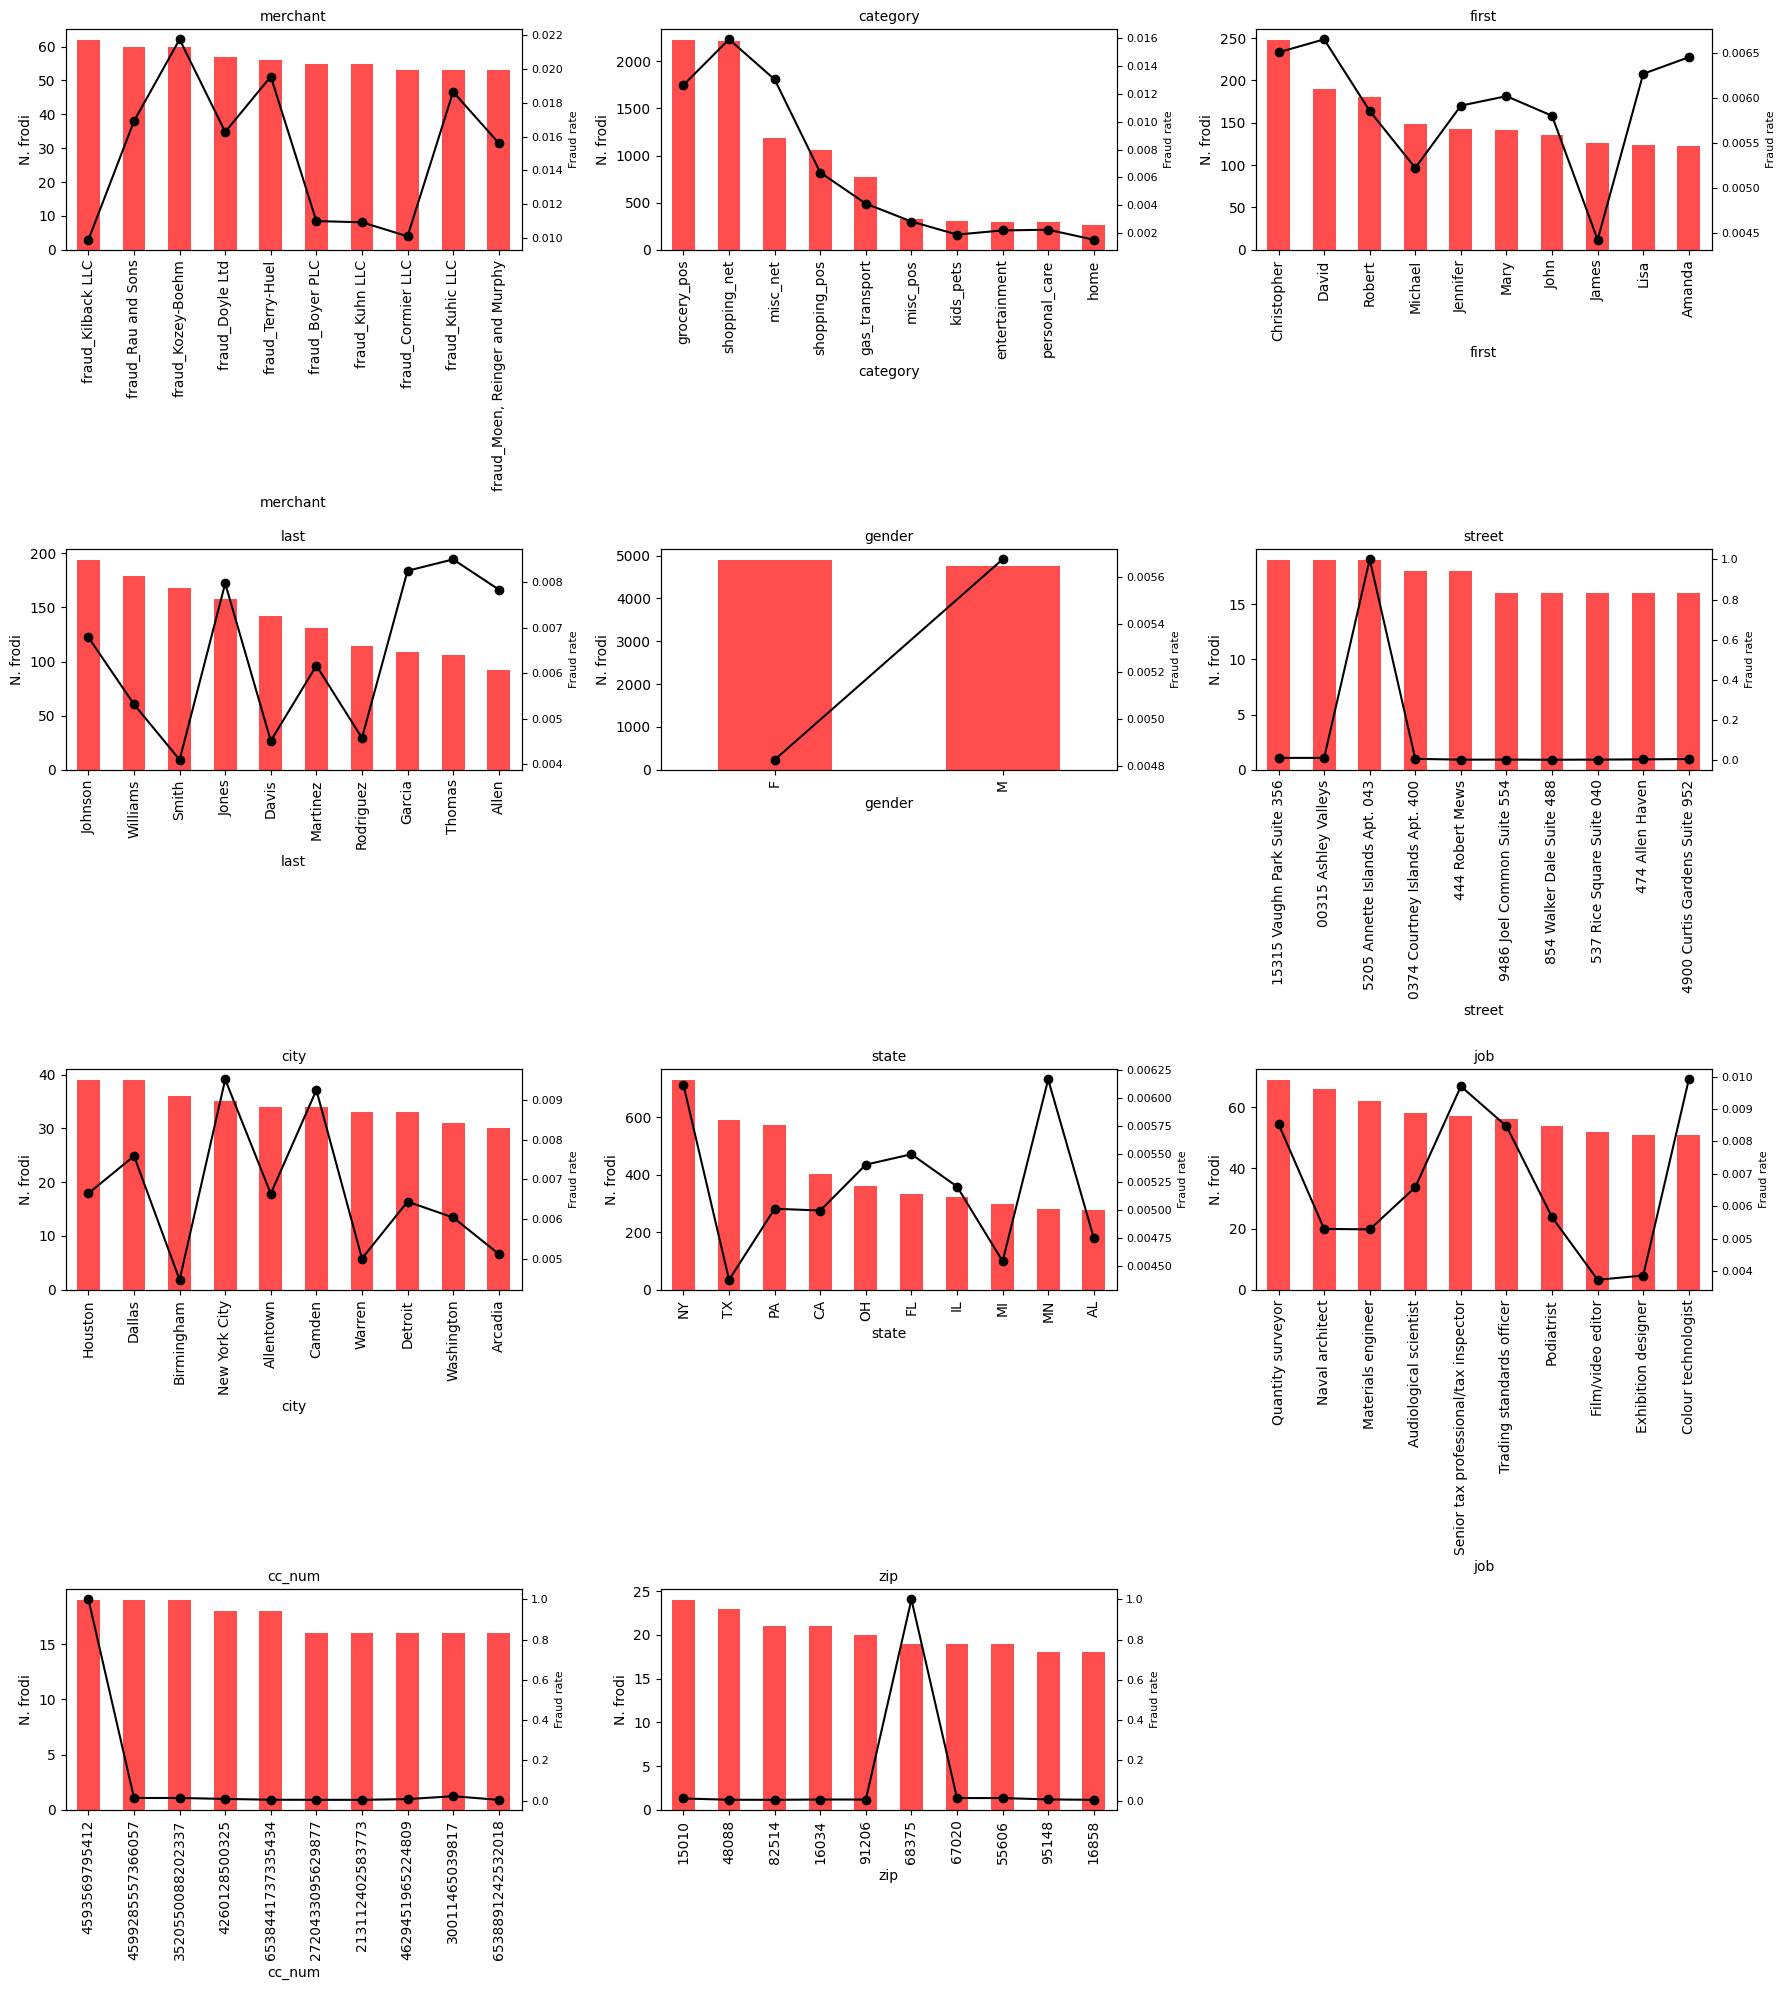

In [48]:
f_dict = {}
cols = [c for c in df_object.columns if c != "is_fraud"]

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cols):
    stats = plot_top_fraud_on_ax(df_object, col, axes[i])
    f_dict[col] = stats #lo utilizzeremo dopo dopo

# Nasconde eventuali subplot vuoti
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [49]:
for i in f_dict:
  print(f_dict[i])

                                            n_fraud  n_txn  fraud_rate
merchant                                                              
fraud_Kozey-Boehm                                60   2758      0.0218
fraud_Herman, Treutel and Dickens                38   1870      0.0203
fraud_Terry-Huel                                 56   2864      0.0196
fraud_Kerluke-Abshire                            50   2635      0.0190
fraud_Mosciski, Ziemann and Farrell              53   2821      0.0188
fraud_Schmeler, Bashirian and Price              52   2788      0.0187
fraud_Kuhic LLC                                  53   2842      0.0186
fraud_Jast Ltd                                   51   2757      0.0185
fraud_Langworth, Boehm and Gulgowski             52   2817      0.0185
fraud_Romaguera, Cruickshank and Greenholt       51   2767      0.0184
fraud_Boyer-Reichert                             51   2779      0.0184
fraud_Heathcote, Yost and Kertzmann              51   2786      0.0183
fraud_

A seguito di un’analisi esplorativa approfondita e di verifiche quantitative sulla distribuzione delle frodi, è stata definita una strategia di trattamento delle principali feature categoriali e identificative del dataset, che guiderà la fase successiva di feature engineering.
L’obiettivo è preservare informazione predittiva, garantire robustezza statistica ed evitare fenomeni di overfitting o leakage temporale.

Le variabili ad alta cardinalità e di tipo identificativo (**merchant, job, city, zip, cc_num**) mostrano una forte eterogeneità nei tassi di frode, spesso caratterizzata da valori estremi (**fino al 100%**) associati a un **numero molto ridotto di osservazioni**. Tali comportamenti sono indicativi di stime statisticamente instabili e non generalizzabili se utilizzate direttamente tramite codifiche categoriali tradizionali (ad esempio **one-hot encoding**).

Per questo motivo, nelle fasi successive del progetto, per le variabili **merchant, job, city e zip** verrà adottata una codifica basata su punteggi di **rischio storico smoothed**, **calcolati in modo incrementale e utilizzando esclusivamente informazioni disponibili prima di ciascuna transazione**. Questo approccio consentirà di:

- attenuare l’effetto di campioni piccoli tramite smoothing rispetto al tasso di frode globale;

- evitare leakage temporale;

- gestire naturalmente nuove modalità non osservate in fase di training;

- ridurre drasticamente la dimensionalità del feature space;

- migliorare la stabilità del modello in uno scenario di produzione.

La variabile **cc_num**, pur mostrando casi isolati di elevata concentrazione di frodi, non verrà utilizzata direttamente come feature in quanto rappresenta un identificativo puro. Tuttavia, sarà impiegata come chiave per la costruzione di feature storiche comportamentali del cliente (**conteggi, recency e tassi di frode smoothed**), che risultano significativamente più informative e **generalizzabili**.

Le variabili anagrafiche altamente specifiche (**first, last, street**) verranno escluse dal modello, poiché caratterizzate da elevata cardinalità, assenza di significato predittivo generalizzabile e natura fortemente identificativa.

Al contrario, le feature a bassa cardinalità e con supporto statistico stabile verranno trattate tramite codifiche categoriali standard. In particolare, **category e state verranno codificate tramite one-hot encoding, mentre gender verrà mantenuta come variabile categoriale binaria**. Queste variabili forniscono contesto informativo utile e risultano robuste sia in fase di addestramento sia in uno scenario di utilizzo operativo.

Nel complesso, le decisioni prese in questa fase hanno l'obiettivo di definire  un piano di feature engineering coerente con il contesto della fraud detection reale, privilegiando **segnali probabilistici robusti e aggregati rispetto a regole deterministiche o codifiche ad alta dimensionalità**, e porre le basi per una modellazione supervisionata efficace e interpretabile.